# Circuit Test

In [ ]:
%pip install umap-learn

In [65]:
import copy
import tempfile
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import rsatoolbox
import torch
from torch.utils.data import Subset

from privacy_and_grokking.config import TrainConfig
from privacy_and_grokking.datasets import create_masking, generate_datasets, mask_dataset
from privacy_and_grokking.models.wrapper import create_model
from privacy_and_grokking.utils import Logger, get_device, setup_mlflow

In [66]:
EXP_NAME = "v4.2.0"
RUN_ID = "b00995f860e44e28947a14b5b93677e0"
STEP = 250_000

In [67]:
setup_mlflow(EXP_NAME)
logger = Logger().setup()
device = get_device()

## Load Stuff

In [68]:
cfg = TrainConfig.model_validate(mlflow.artifacts.load_dict(f"runs:/{RUN_ID}/training_config.json"))

In [69]:
train_full, test = generate_datasets(cfg.dataset)
masking = create_masking(
    config=cfg.dataset_mask,
    num_samples=len(train_full),
    num_classes=train_full.num_classes,
)
train = mask_dataset(
    masking,
    train_full,
    cfg.dataset_mask_idx,
)
input_shape = train_full.input_shape
num_classes = train_full.num_classes
print(len(train_full), len(train), len(test), input_shape, num_classes)

60000 29761 10000 torch.Size([1, 28, 28]) 10


In [70]:
with tempfile.TemporaryDirectory() as tmpdir:
    artifact_uri = f"runs:/{RUN_ID}/checkpoints/{STEP}/model.pth"
    mlflow.artifacts.download_artifacts(
        artifact_uri=artifact_uri,
        dst_path=tmpdir,
    )
    model_path = Path(tmpdir) / "model.pth"
    state_dict = torch.load(
        model_path,
        map_location=device,
        weights_only=True,
    )
model = create_model(
    name=cfg.model,
    input_dim=input_shape,
    num_classes=num_classes,
    initialization_scale=None,
)
model.to(device)
model.load_state_dict(state_dict)
model.eval()

MLP(
  (fc1): Linear(in_features=784, out_features=200, bias=True)
  (fc2): Linear(in_features=200, out_features=200, bias=True)
  (fc3): Linear(in_features=200, out_features=10, bias=True)
)

Why we cannot use the Hessian directly:

- `1 Gibibyte` 8589934592 = 8 * 1024 * 1024 * 1024
- `Number of parameters` 199210 = (784 + 1) * 200 + (200 + 1) * 200 + (200 + 1) * 10
- `Hessian Matrix Storage` 39684624100 = `Number of parameters` ** 2
- `In bit` 1269907971200 = `Hessian Matrix Storage` * 32 | since we are using float32
- `In Gibibyte` 147.84 = `In bit` / `1 Gibibyte`

We would need about 150 GB of RAM

## Data Selection

In [71]:
def choose_first_x(dataset, label, num):
    idxs = []
    for idx, (_, y) in enumerate(dataset):
        if y == label:
            idxs.append(idx)
            if len(idxs) == num:
                break
    return idxs

## Hook

In [72]:
activations = defaultdict(list)


def save_activations(name):
    def hook(model, input, output):
        global activations
        activations[name].append(output.detach().clone().cpu())

    return hook


handler = []
for name, module in model.named_modules():
    if isinstance(module, torch.nn.Linear):
        module._forward_hooks.clear()
        handle = module.register_forward_hook(save_activations(name))
        handler.append(handle)

## Plots

In [73]:
def plot_activations(activations_train, activations_test, relu: bool = False):
    layers = [name for name in activations_train if name in activations_test]
    num_layers = len(layers)
    fig, axes = plt.subplots(num_layers, 2, figsize=(12, 3 * num_layers), sharey="row")
    fig.suptitle("Layer Activations: Train vs Test", fontsize=16)

    for i, name in enumerate(layers):
        ax_train = axes[i, 0]
        for data_train in activations_train[name]:
            if relu and (i < len(layers) - 1):
                data_train = torch.nn.functional.relu(data_train)
            ax_train.plot(data_train.numpy().flatten(), alpha=0.5)
        ax_train.set_ylabel(f"{name}\nActivation")
        # ax_train.set_yscale('log')
        if i == 0:
            ax_train.set_title("Train Set")
        ax_test = axes[i, 1]
        for data_test in activations_test[name]:
            if relu and (i < len(layers) - 1):
                data_test = torch.nn.functional.relu(data_test)
            ax_test.plot(data_test.numpy().flatten(), alpha=0.5)
        if i == 0:
            ax_test.set_title("Test Set")
        # ax_test.set_yscale('log')

    plt.xlabel("Flattened Neuron Index")
    plt.show()

In [74]:
def plot_rdms(train_sel, test_sel, train_activations, test_activations, method="correlation"):
    datasets = []

    # Setup
    conds = np.repeat(np.arange(num_classes), 5)
    all_conds = np.concatenate([conds, conds])
    sessions = np.concatenate([np.ones(len(train_sel)), np.ones(len(test_sel)) * 2])

    def get_rdm_matrix(measurements, name):
        ds = rsatoolbox.data.Dataset(
            measurements.numpy(),
            descriptors=dict(layer=name),
            # obs_descriptors={'class': all_conds, 'sessions': sessions}
        )
        # Calculate individually to avoid feature-count broadcasting errors
        rdm = rsatoolbox.rdm.calc_rdm(ds, method=method)
        return rdm.get_matrices()[0]

    layer_dict = {}
    # Labels
    train_labels = torch.tensor([y for _, y in train_sel])
    test_labels = torch.tensor([y for _, y in test_sel])
    measurements = torch.nn.functional.one_hot(
        torch.concat((train_labels, test_labels)), num_classes=num_classes
    ).float()
    datasets.append(
        rsatoolbox.data.Dataset(measurements, descriptors=dict(layer="Labels"))
    )  # , obs_descriptors={'conds': all_conds, 'sessions': sessions}))
    layer_dict["Labels"] = get_rdm_matrix(measurements, "Labels")
    # datasets.append(rsatoolbox.data.Dataset(measurements, descriptors=dict(layer="Labels"), obs_descriptors={'conds': all_conds, 'sessions': sessions}))

    # Images
    train_samples = torch.concat([x for x, _ in train_sel]).flatten(1)
    test_samples = torch.concat([x for x, _ in test_sel]).flatten(1)
    measurements = torch.concat((train_samples, test_samples))
    layer_dict["Images"] = get_rdm_matrix(measurements, "Images")
    # datasets.append(rsatoolbox.data.Dataset(measurements, descriptors=dict(layer="Images"), obs_descriptors={'conds': all_conds, 'sessions': sessions}))

    # Layer
    for layer in train_activations:
        train_act = torch.concat(train_activations[layer])
        test_act = torch.concat(test_activations[layer])
        measurements = torch.concat((train_act, test_act))
        layer_dict[layer] = get_rdm_matrix(measurements, layer)
        # datasets.append(rsatoolbox.data.Dataset(measurements, descriptors=dict(layer=layer), obs_descriptors={'conds': all_conds, 'sessions': sessions}))
    # rdms = rsatoolbox.rdm.calc_rdm(datasets, method="crossnobis", descriptor='conds', cv_descriptor='sessions')
    # layer_dict =  {dataset.descriptors["layer"]: rdms.get_matrices()[i] for i, dataset in enumerate(datasets)}

    num_layers = len(layer_dict)
    if num_layers == 0:
        print("The dictionary is empty.")
        return
    fig, axes = plt.subplots(1, num_layers, figsize=(4 * num_layers, 4))
    if num_layers == 1:
        axes = [axes]

    for ax, (layer_name, matrix) in zip(axes, layer_dict.items()):
        im = ax.imshow(matrix, cmap="magma_r", vmin=0, vmax=1)
        ax.set_title(layer_name, fontsize=14)
        ax.set_xticks([])
        ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

In [75]:
from matplotlib.lines import Line2D
from sklearn.manifold import TSNE


def plot_activations_tsne(train_dict, test_dict, train_labels, test_labels):
    layers = list(train_dict.keys())
    num_layers = len(layers)

    fig, axes = plt.subplots(1, num_layers, figsize=(7 * num_layers, 6), squeeze=False)
    for i, layer in enumerate(layers):
        ax = axes[0, i]

        train_acts = np.array([a.flatten() for a in train_dict[layer]])
        test_acts = np.array([a.flatten() for a in test_dict[layer]])

        combined_acts = np.vstack([train_acts, test_acts])

        tsne = TSNE(
            perplexity=50, n_components=2, random_state=42, init="pca", learning_rate="auto"
        )
        embeddings = tsne.fit_transform(combined_acts)

        train_emb = embeddings[: len(train_acts)]
        test_emb = embeddings[len(train_acts) :]

        # 4. Plot Training points (Circles)
        scatter_train = ax.scatter(
            train_emb[:, 0],
            train_emb[:, 1],
            c=train_labels,
            marker="o",
            cmap="tab10",
            alpha=0.5,
            edgecolors="none",
        )

        # 5. Plot Testing points (Crosses)
        scatter_test = ax.scatter(
            test_emb[:, 0], test_emb[:, 1], c=test_labels, marker="x", cmap="tab10", alpha=1.0, s=50
        )

        ax.set_title(f"Layer: {layer}", fontsize=14)
        ax.set_xlabel("Dimension 1")
        ax.set_ylabel("Dimension 2")

        # Add legend only to the last subplot to avoid clutter
        if i == num_layers - 1:
            # Class color legend
            legend_class = ax.legend(
                *scatter_train.legend_elements(),
                title="Classes",
                loc="upper left",
                bbox_to_anchor=(1, 1),
            )
            ax.add_artist(legend_class)

            # Split marker legend
            marker_elements = [
                Line2D(
                    [0],
                    [0],
                    marker="o",
                    color="w",
                    label="Train",
                    markerfacecolor="gray",
                    markersize=10,
                ),
                Line2D(
                    [0],
                    [0],
                    marker="x",
                    color="w",
                    label="Test",
                    markeredgecolor="black",
                    markersize=10,
                ),
            ]
            ax.legend(
                handles=marker_elements, title="Split", loc="lower left", bbox_to_anchor=(1, 0)
            )

    plt.tight_layout()

In [76]:
activations.clear()
train_labels = []
with torch.no_grad():
    for x, y in train:
        x, y = x.to(device), y.to(device)
        _ = model(x)
        train_labels.append(y)
train_activations = copy.copy(activations)

activations.clear()
test_labels = []
with torch.no_grad():
    for x, y in test:
        x, y = x.to(device), y.to(device)
        _ = model(x)
        test_labels.append(y)
test_activations = copy.copy(activations)

In [77]:
def run(label: int, relu: bool = False):
    train_idxs = choose_first_x(train, label, 10)
    test_idxs = choose_first_x(test, label, 10)

    train_sel = Subset(train, train_idxs)
    test_sel = Subset(test, test_idxs)

    train_activations_sel = {
        layer: [activations[i] for i in train_idxs]
        for layer, activations in train_activations.items()
    }
    test_activations_sel = {
        layer: [activations[i] for i in test_idxs]
        for layer, activations in test_activations.items()
    }

    plot_activations(train_activations_sel, test_activations_sel, relu=relu)
    plot_rdms(train_sel, test_sel, train_activations_sel, test_activations_sel)

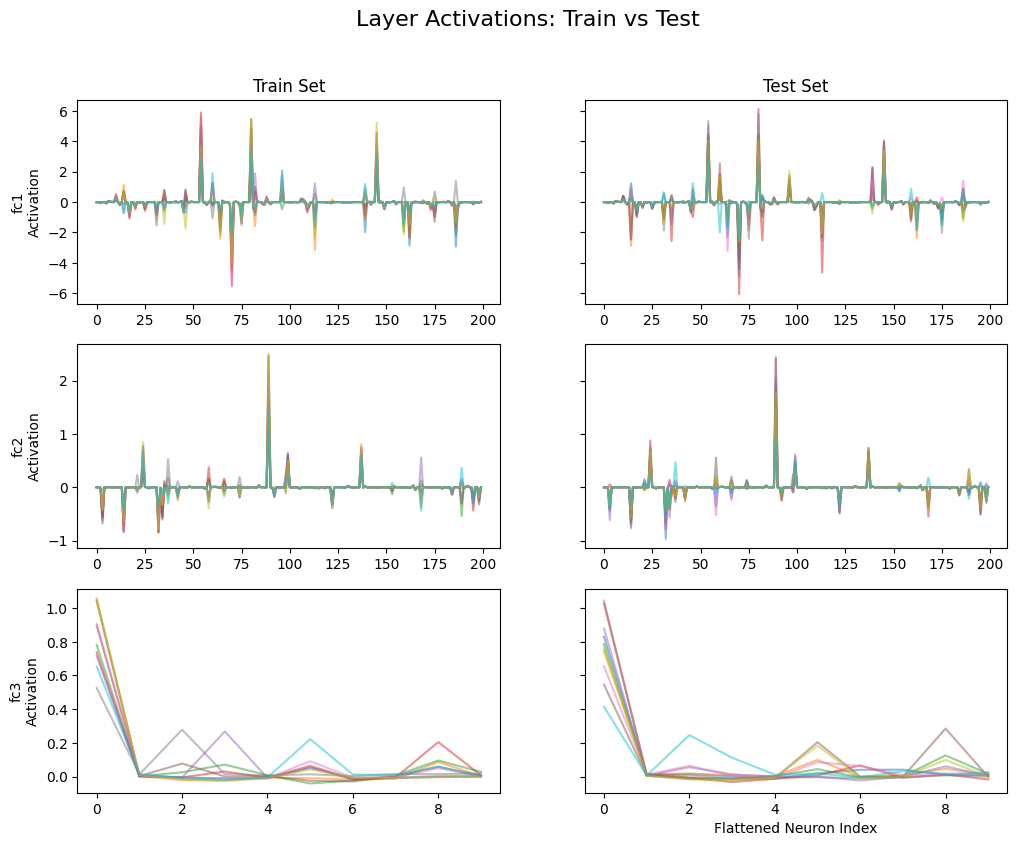

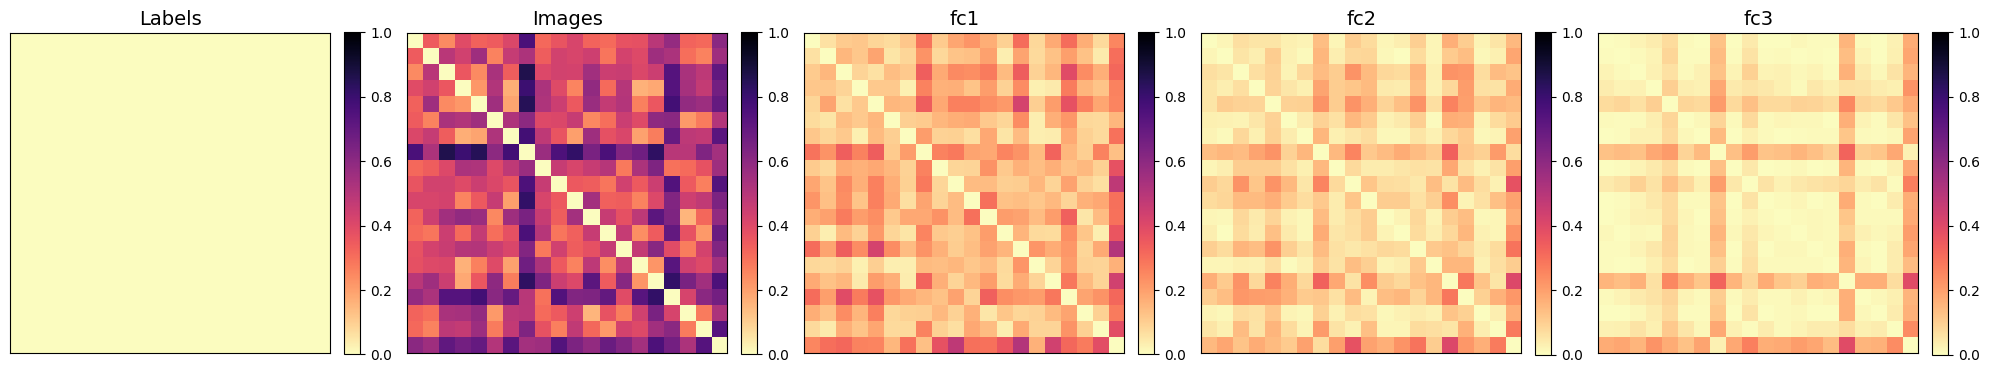

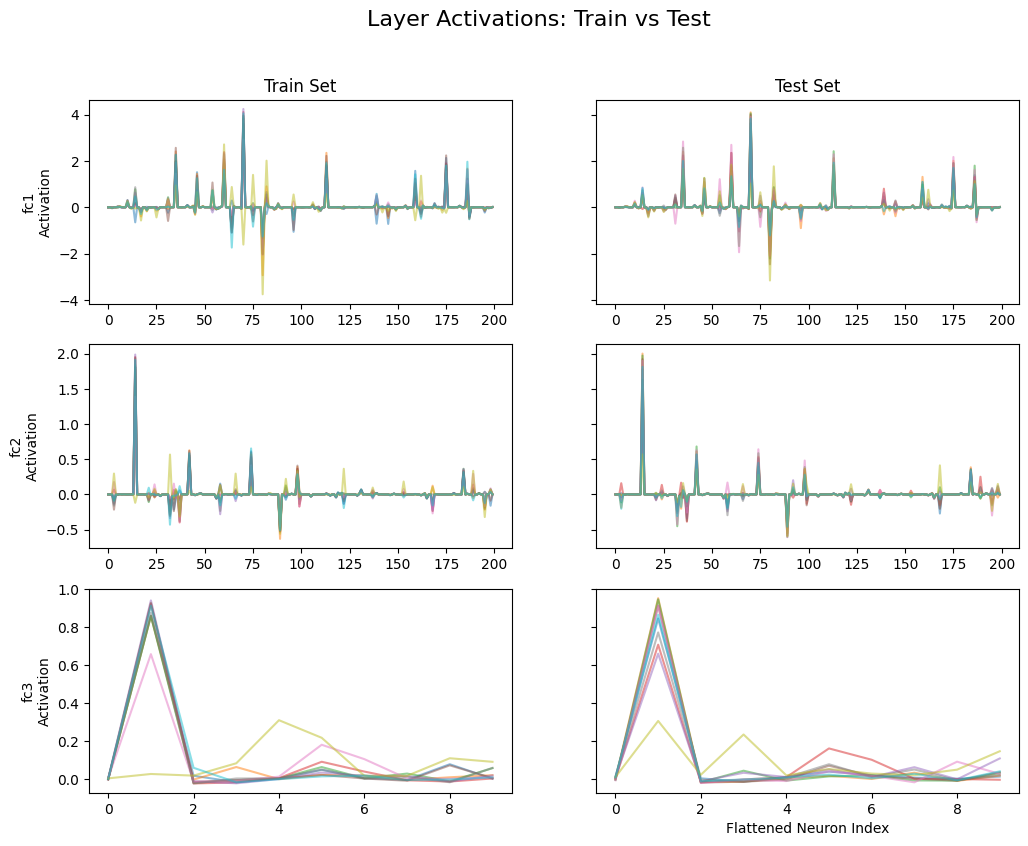

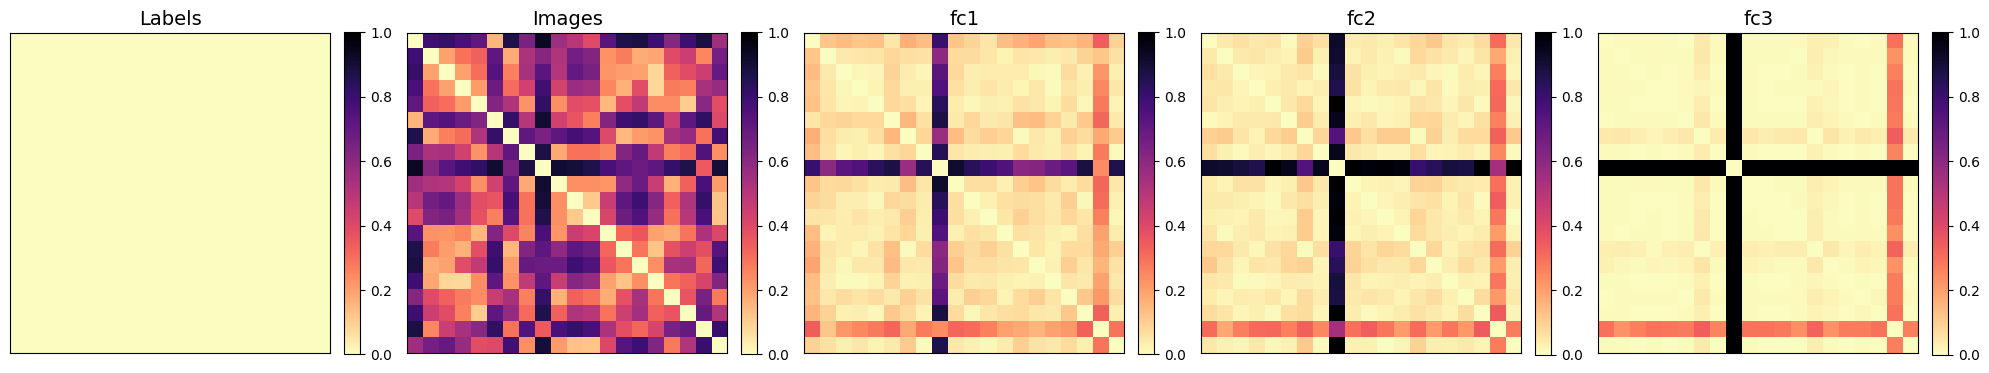

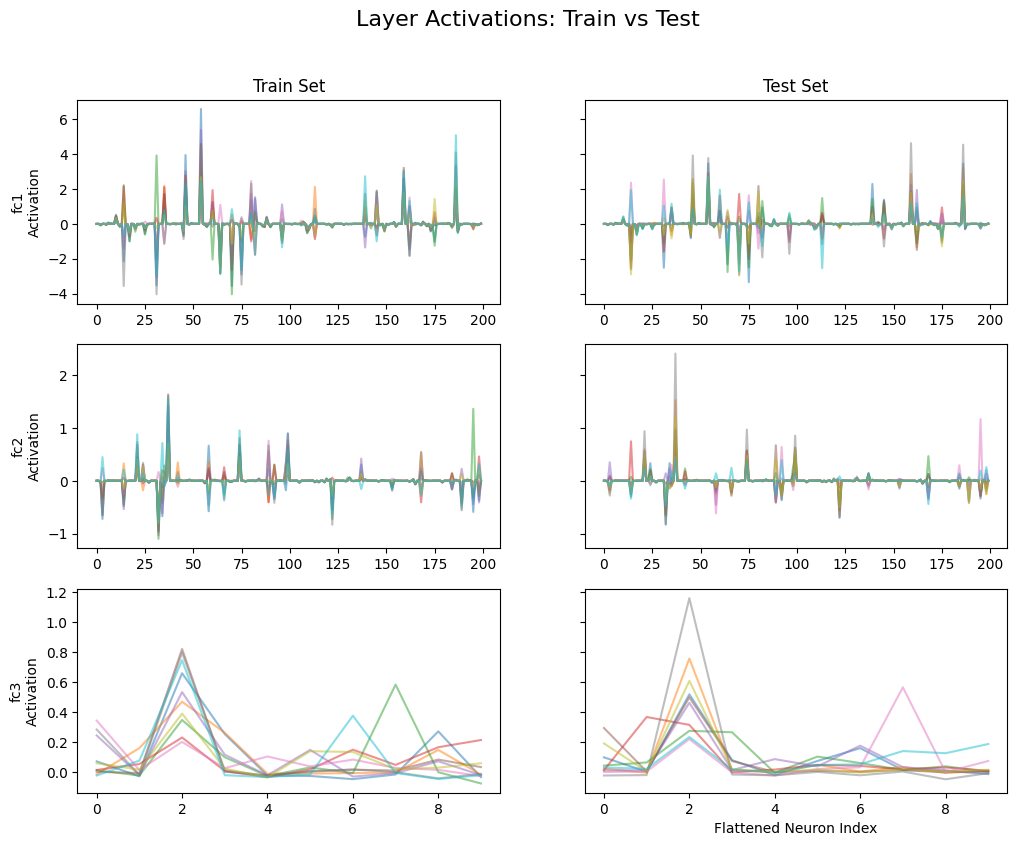

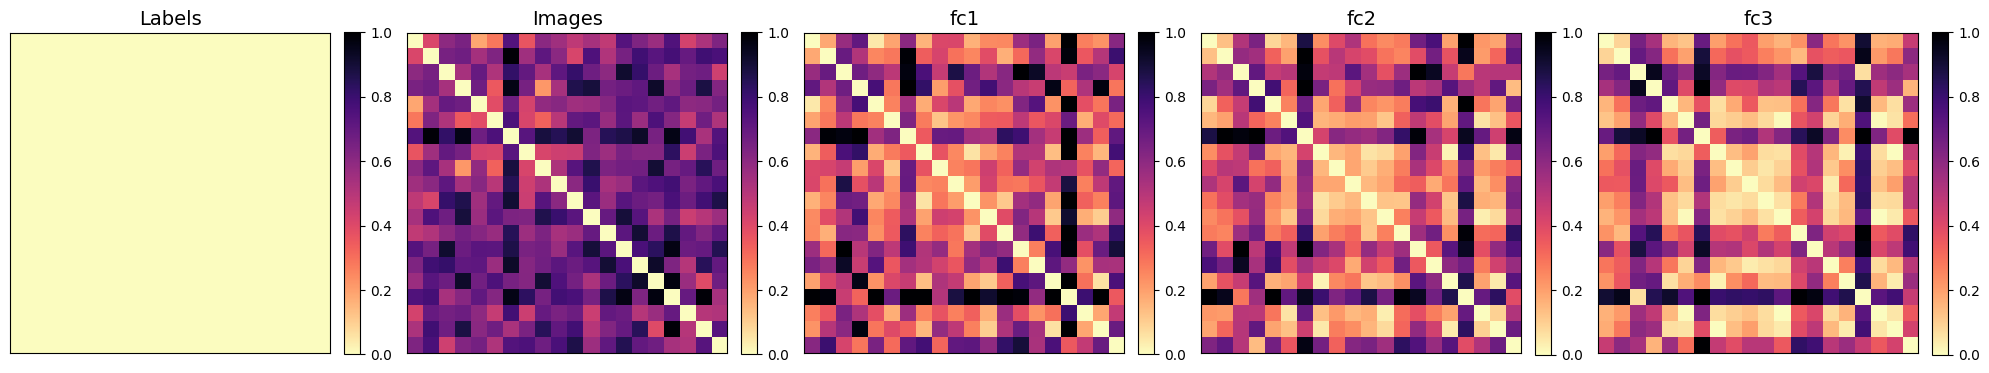

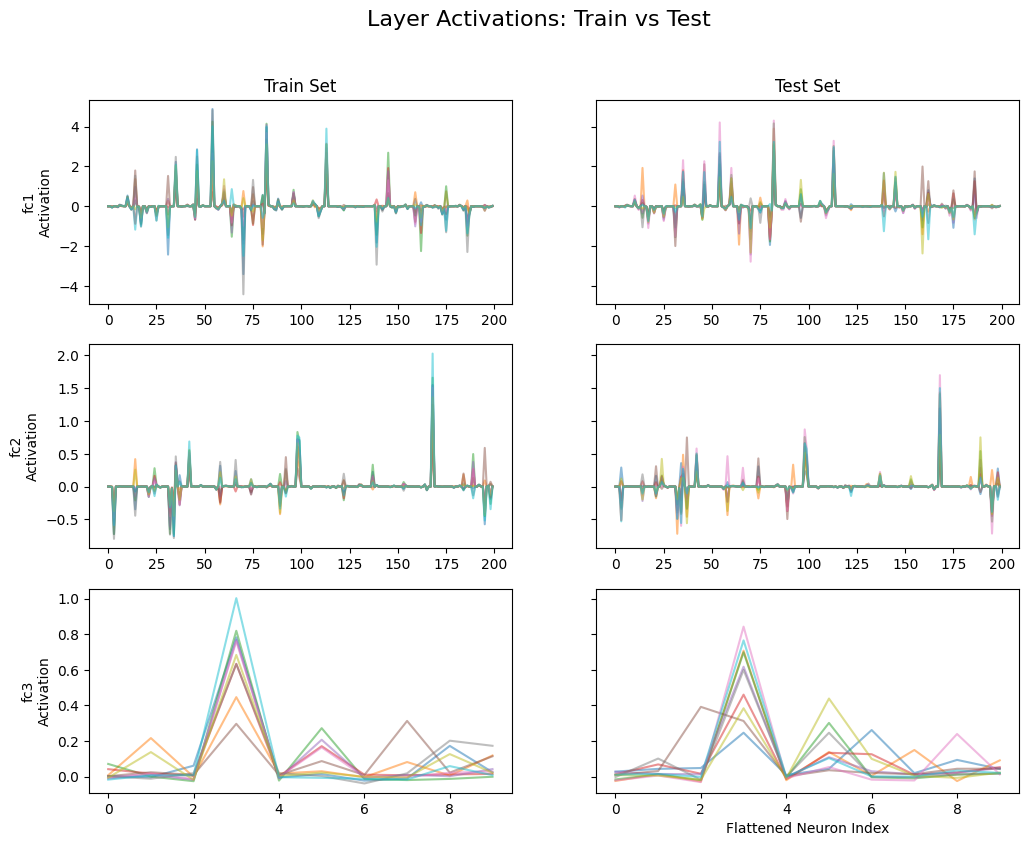

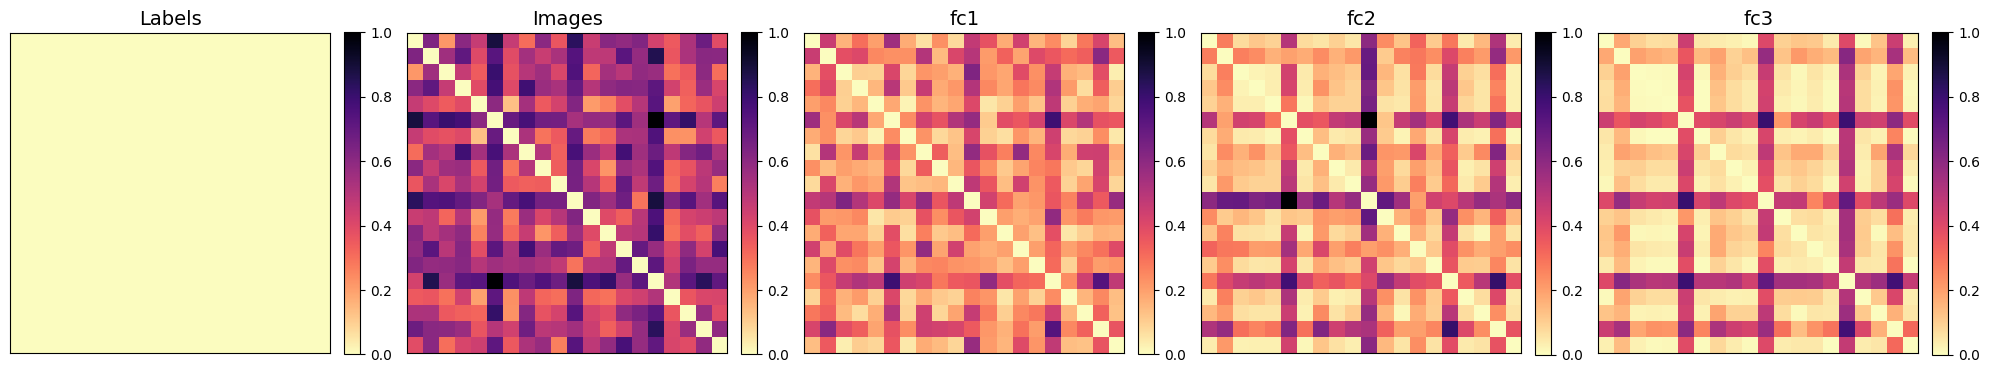

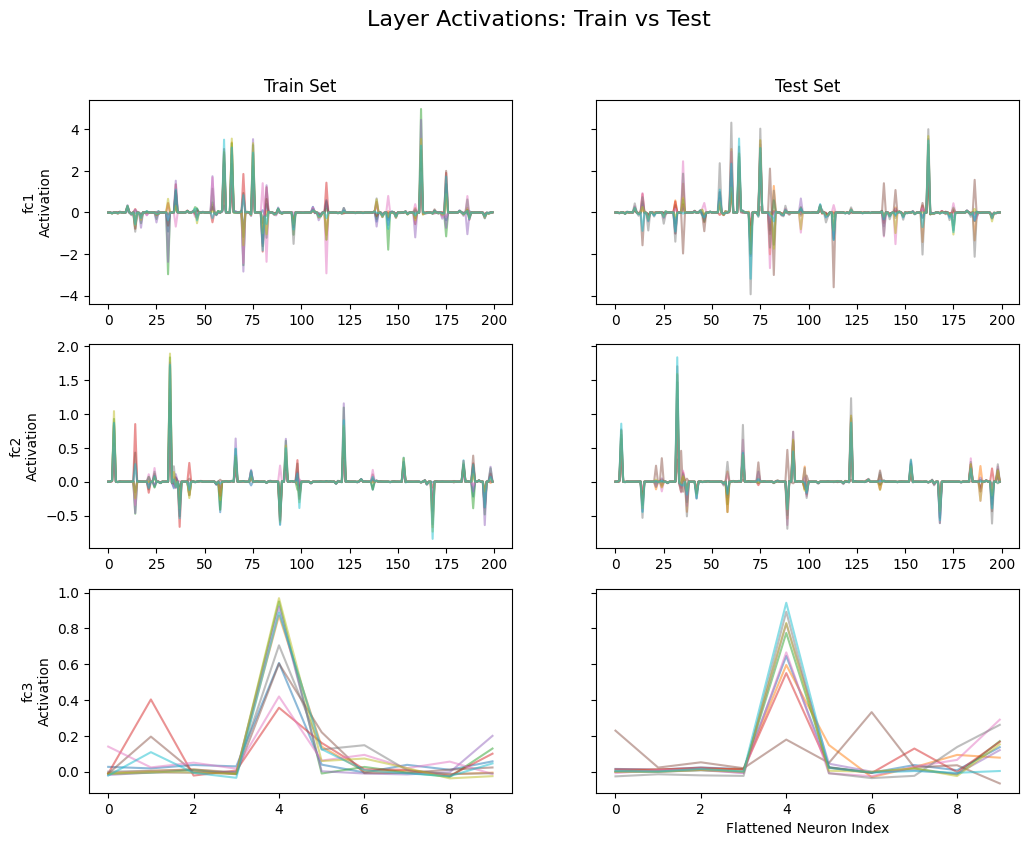

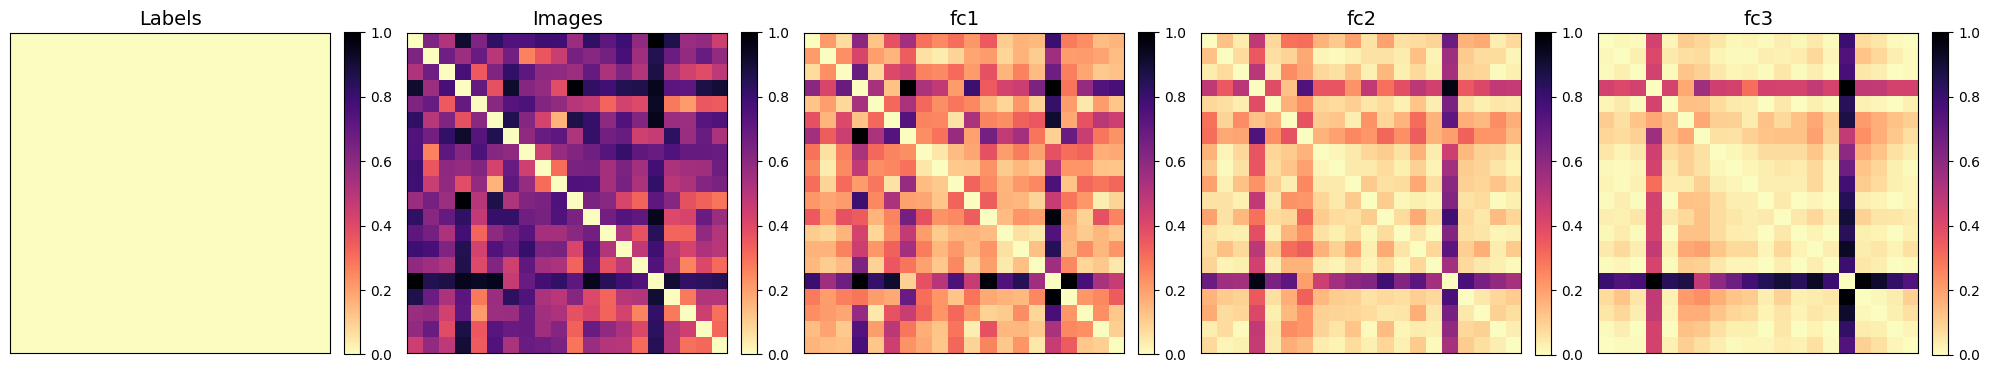

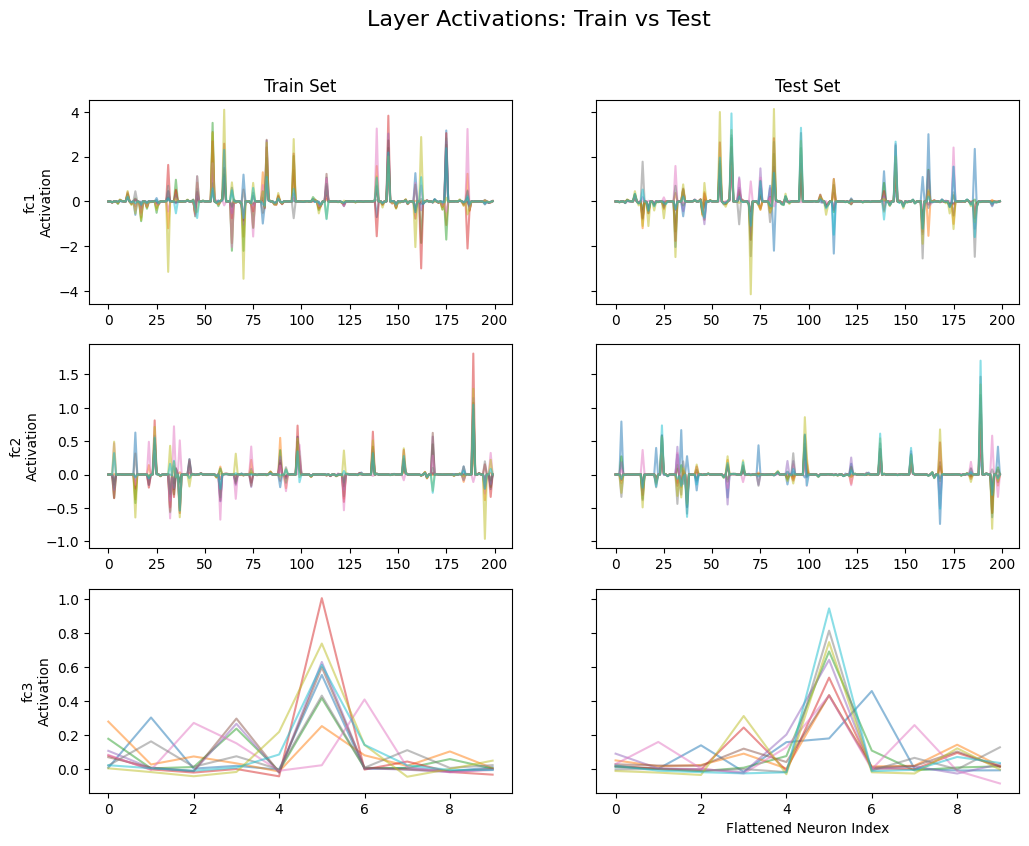

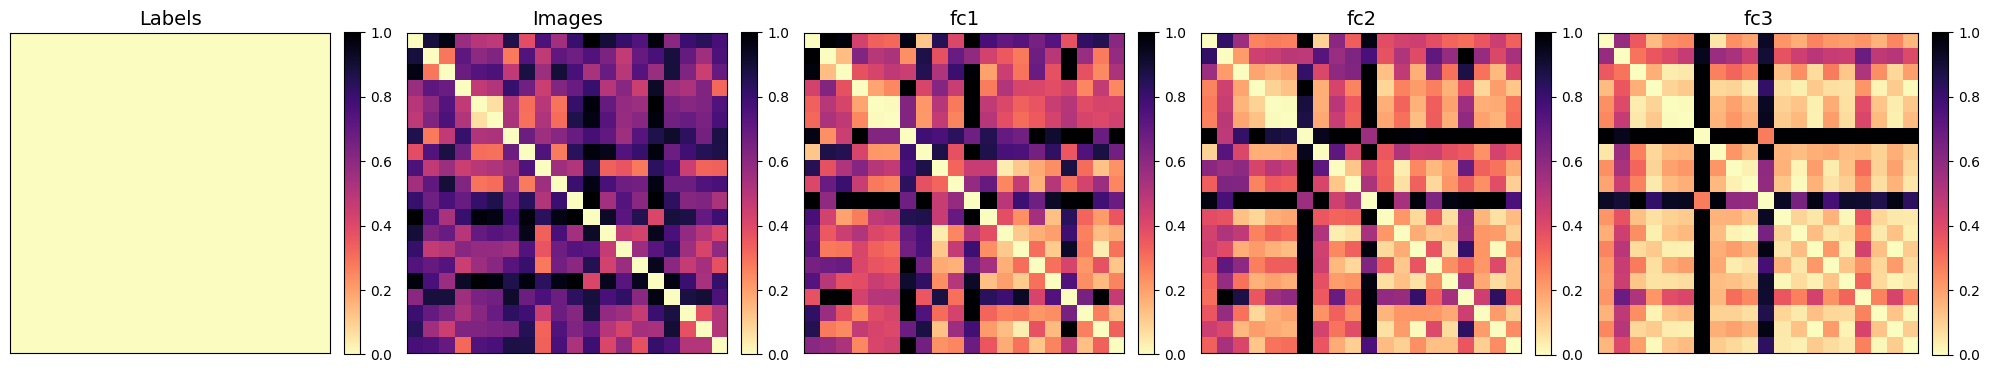

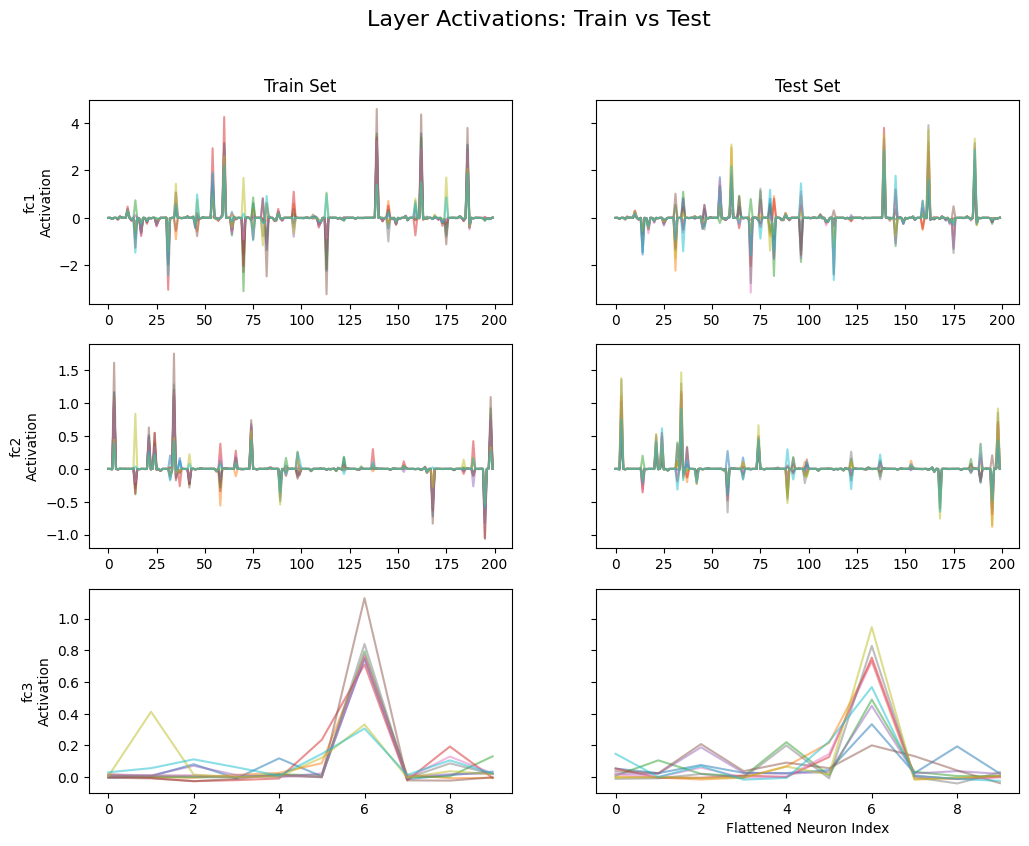

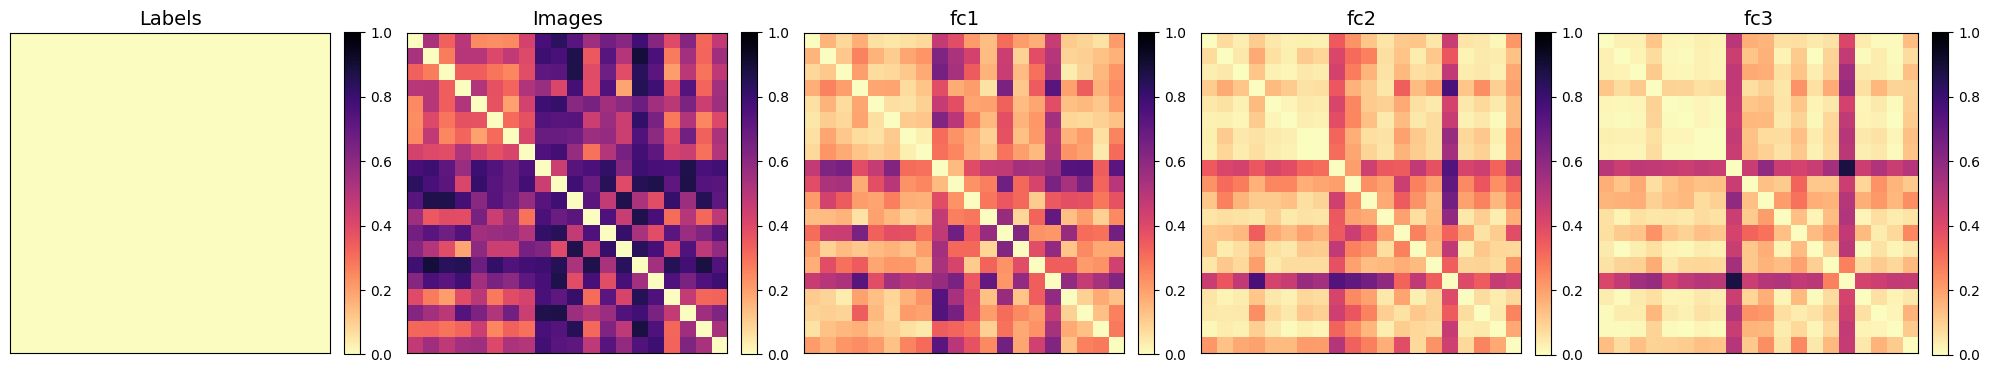

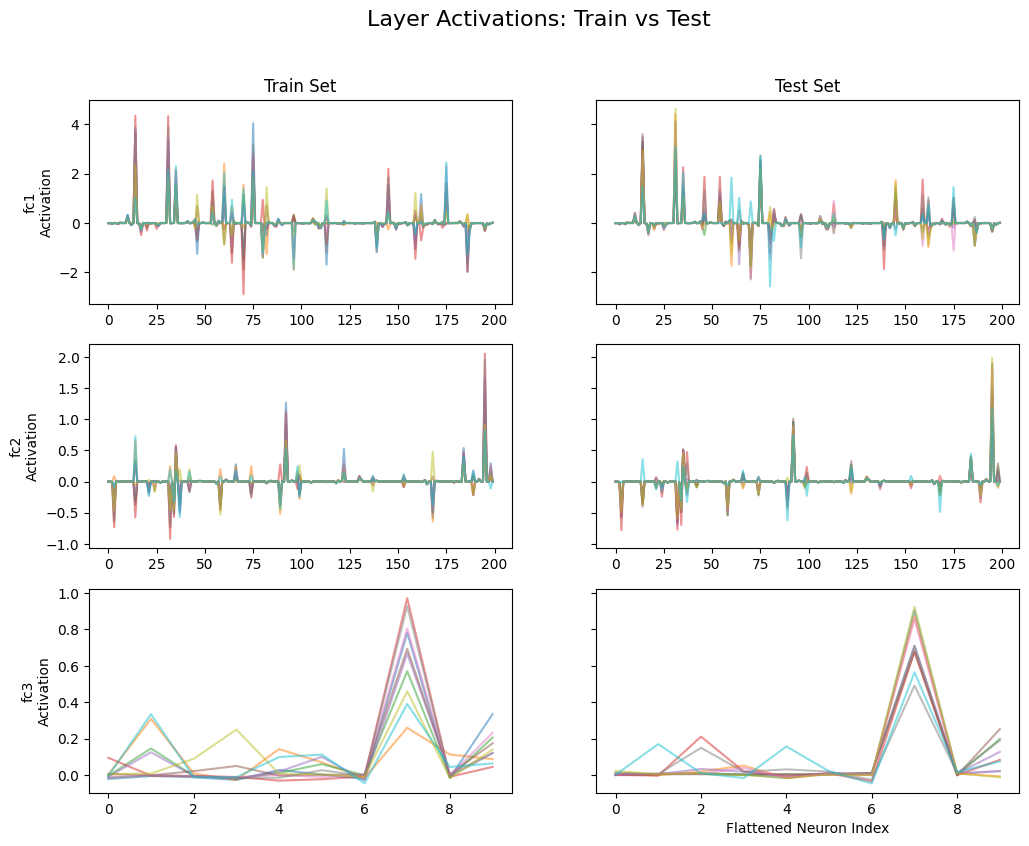

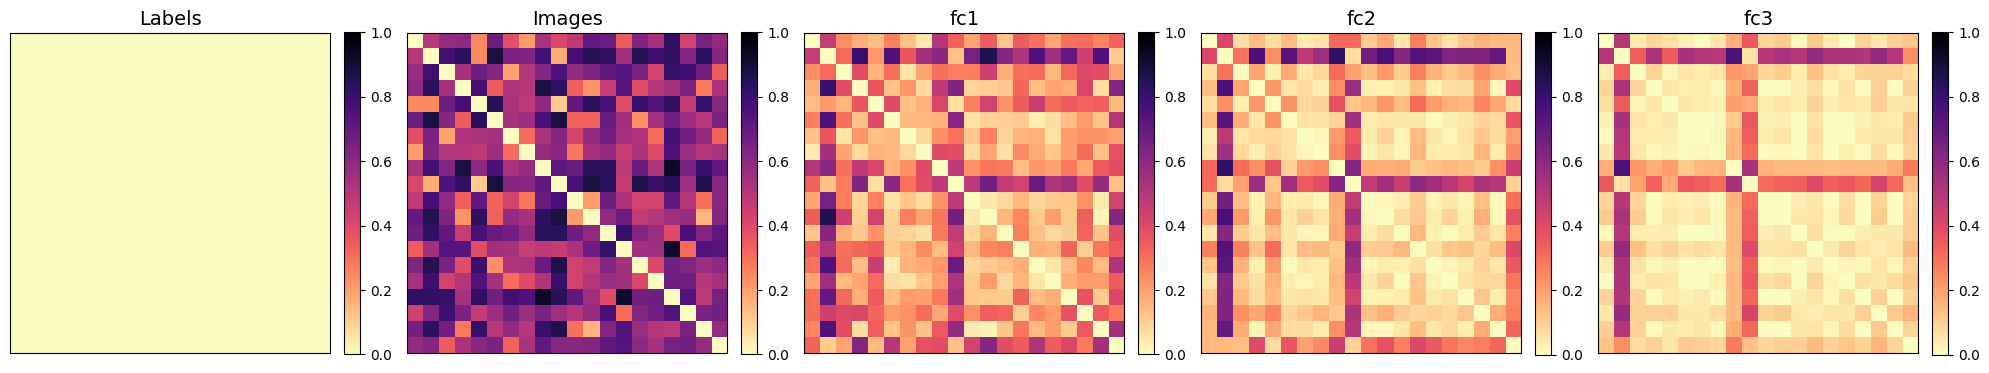

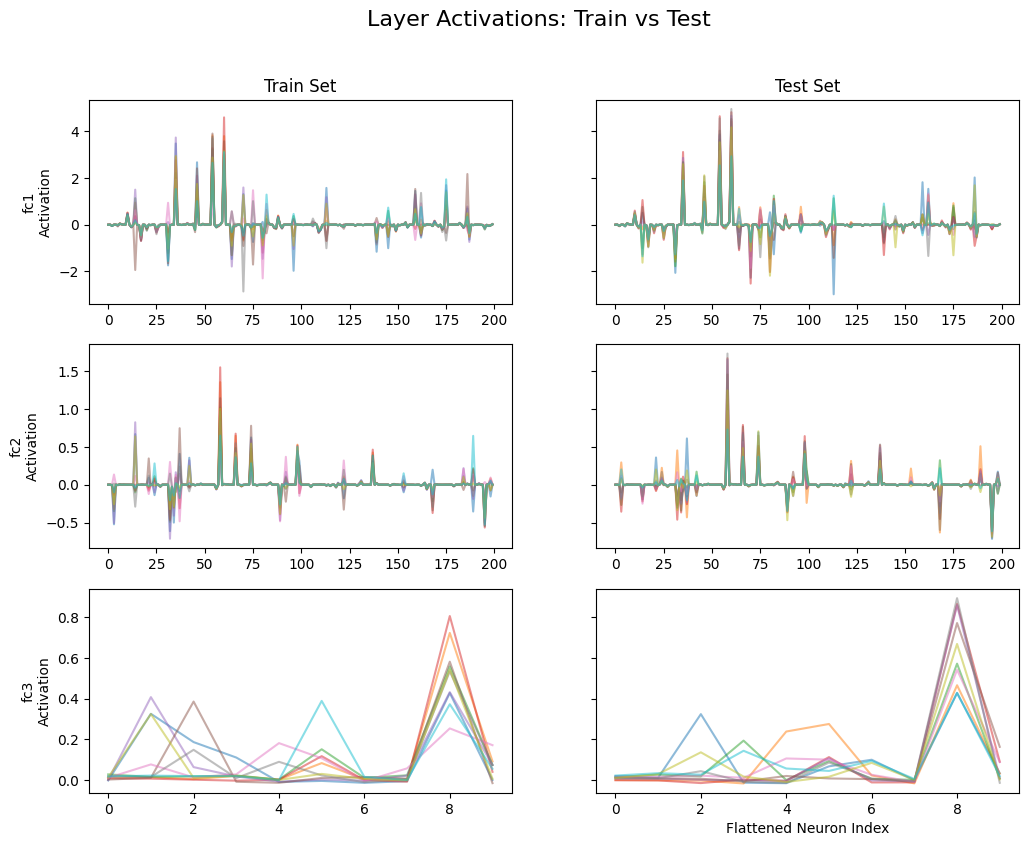

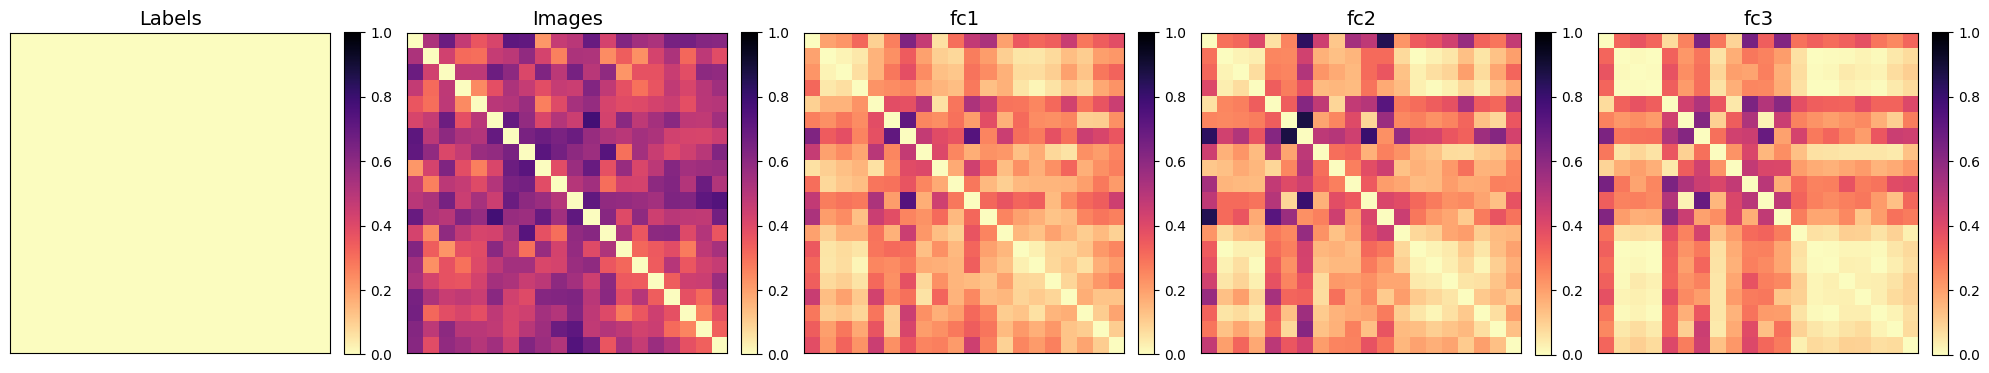

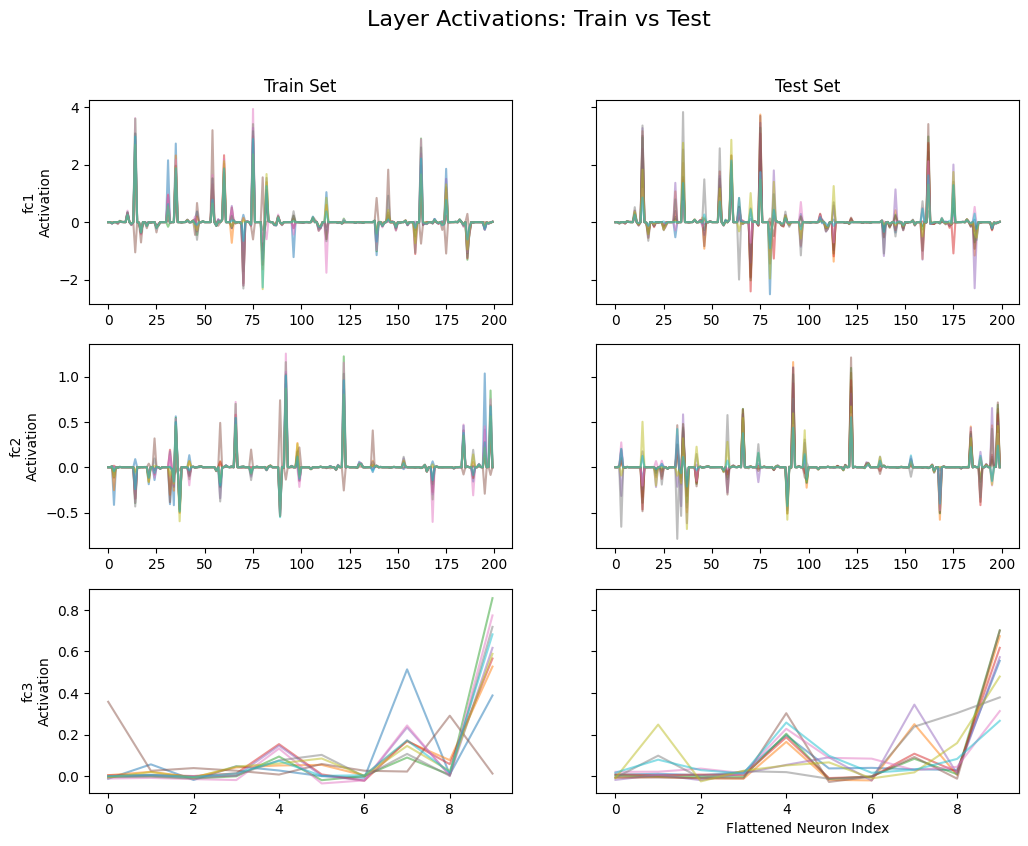

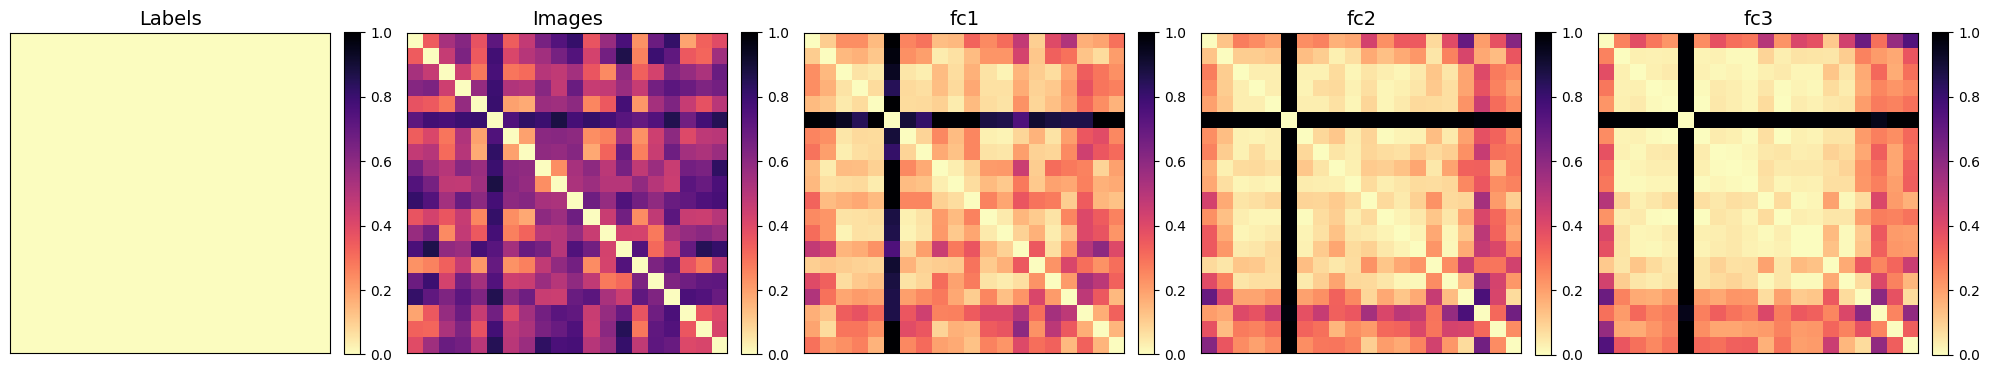

In [78]:
for i in range(num_classes):
    run(i, relu=False)

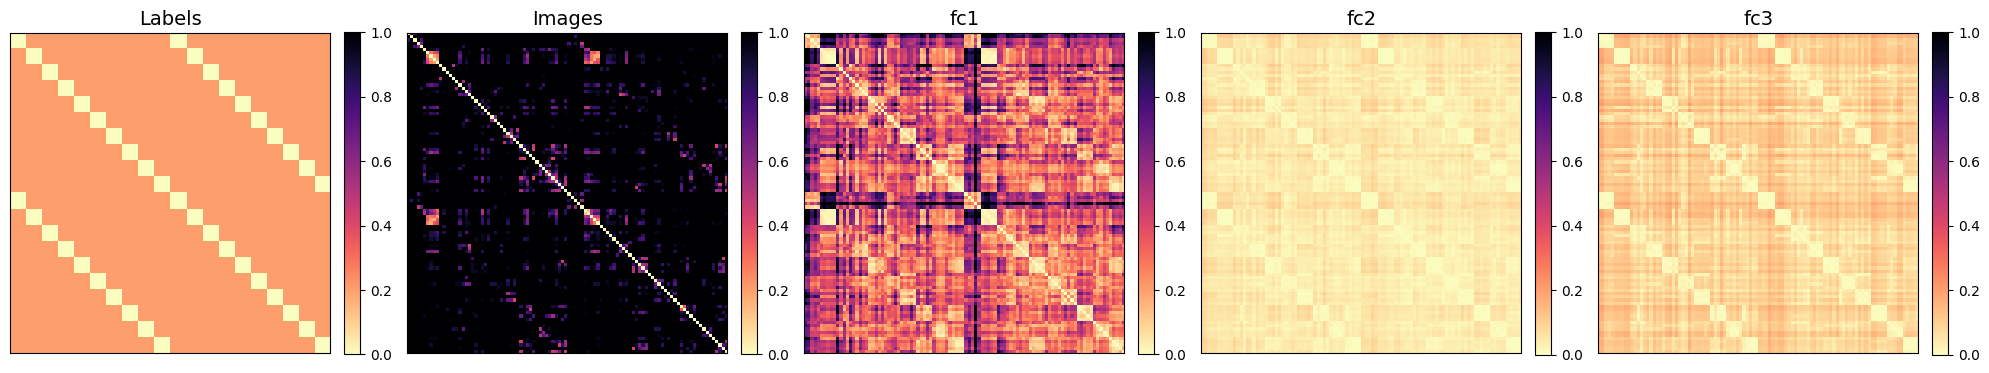

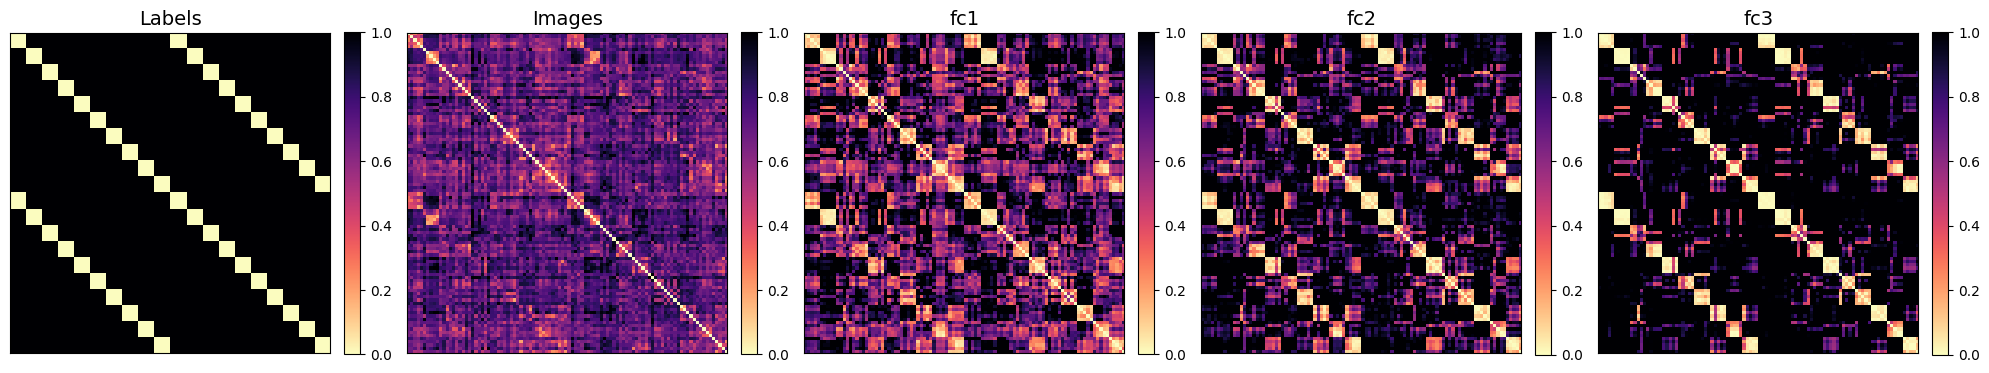

In [79]:
train_idxs = [x for label in range(num_classes) for x in choose_first_x(train, label, 5)]
test_idxs = [x for label in range(num_classes) for x in choose_first_x(test, label, 5)]

train_sel = Subset(train, train_idxs)
test_sel = Subset(test, test_idxs)

train_activations_sel = {
    layer: [activations[i] for i in train_idxs] for layer, activations in train_activations.items()
}
test_activations_sel = {
    layer: [activations[i] for i in test_idxs] for layer, activations in test_activations.items()
}

plot_rdms(train_sel, test_sel, train_activations_sel, test_activations_sel, method="euclidean")
plot_rdms(train_sel, test_sel, train_activations_sel, test_activations_sel, method="correlation")

In [80]:
import umap


def visualize_activations(group_a, group_b, group_a_labels, group_b_labels, layer_name):
    data_a = np.array(group_a[layer_name])
    data_b = np.array(group_b[layer_name])
    combined_data = np.vstack([data_a, data_b]).squeeze()

    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    embedding = reducer.fit_transform(combined_data)

    emb_a = embedding[: len(data_a)]
    emb_b = embedding[len(data_a) :]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

    scatter1 = ax1.scatter(emb_a[:, 0], emb_a[:, 1], c=group_a_labels)
    ax1.set_title(f"Train: {layer_name}")
    scatter2 = ax2.scatter(emb_b[:, 0], emb_b[:, 1], c=group_b_labels)
    ax2.set_title(f"Test: {layer_name}")
    cbar = fig.colorbar(scatter2, ax=[ax1, ax2])
    cbar.set_label("Class (Index)")

    plt.suptitle(f"UMAP Projection of Activations - {layer_name}")
    plt.show()


# Example usage:
# visualize_activations(group_a_dict, group_b_dict, 'layer_1')

/data_rechenknecht03_2/students/holzapfel/privacy-and-grokking/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


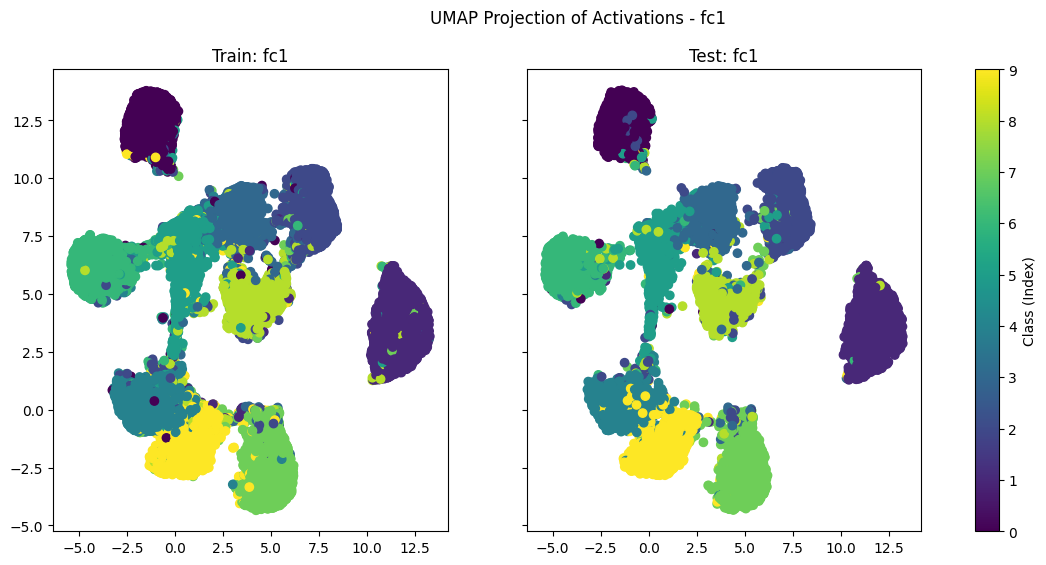

/data_rechenknecht03_2/students/holzapfel/privacy-and-grokking/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


KeyboardInterrupt: 

In [81]:
for layer in train_activations:
    visualize_activations(
        train_activations,
        test_activations,
        torch.tensor(train_labels).cpu().numpy(),
        torch.tensor(test_labels).cpu().numpy(),
        layer,
    )

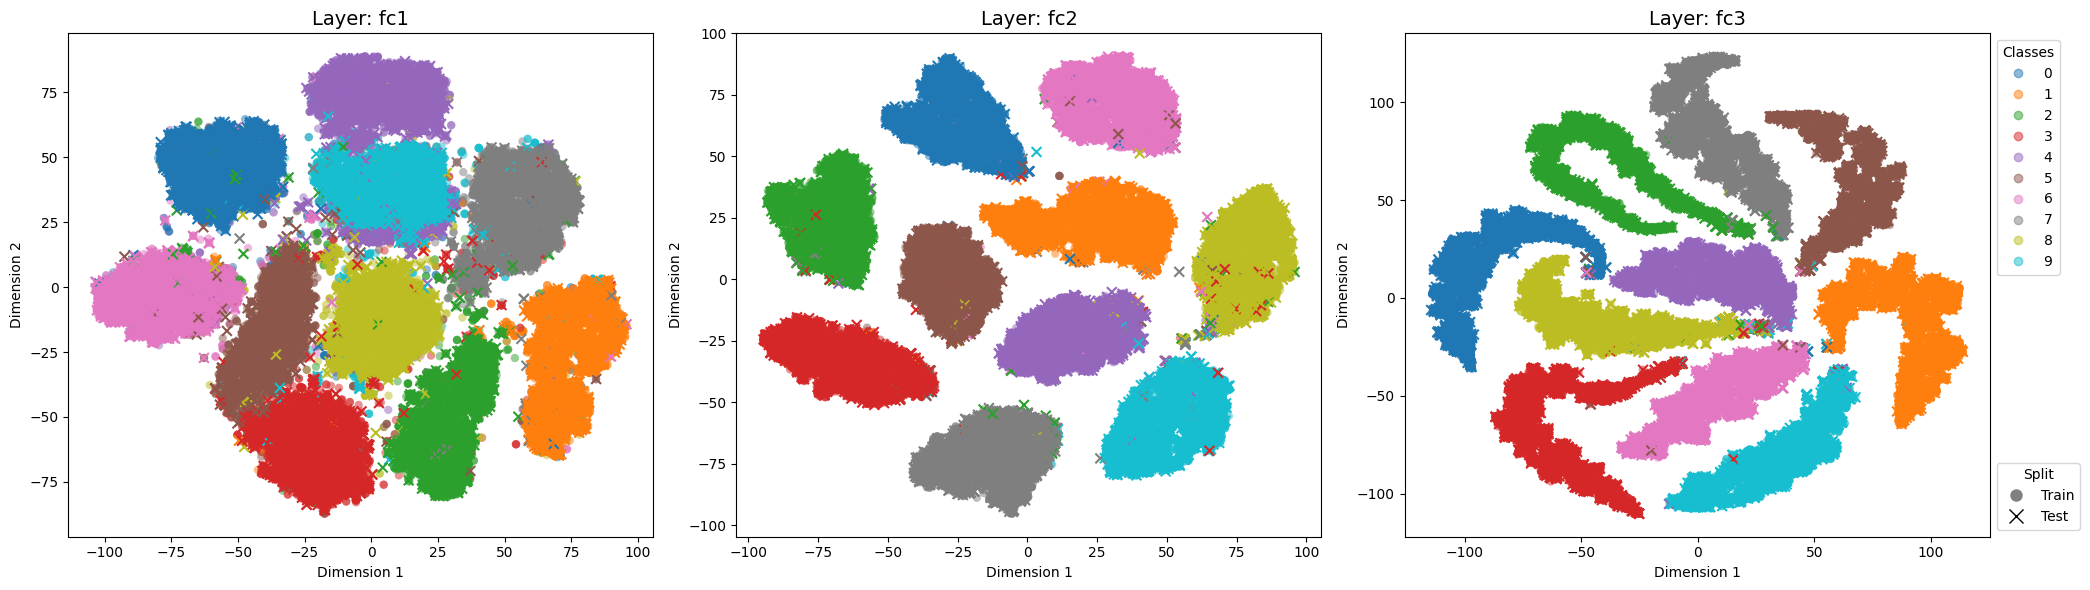

In [ ]:
plot_activations_tsne(
    train_activations,
    test_activations,
    torch.tensor(train_labels).cpu(),
    torch.tensor(test_labels).cpu(),
)